<a href="https://colab.research.google.com/github/hezioquan12/Caculate_Score/blob/main/MLP_model_and_kfold_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, Subset, random_split

import torchvision
import torchvision.datasets as datasets
from torchvision import transforms as transforms
from torchvision.transforms import functional as TF

import kagglehub

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.model_selection import StratifiedKFold

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Config

In [ ]:
# Đường dẫn lưu trọng số sau khi train
MODEL_SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Brics2025_MLP_kfold'
MODEL_PATH = os.path.join(MODEL_SAVE_DIR, 'best_mlp_model.pth')
KAGGLE_DATASET = "briscdataset/brisc2025"
CLASSIFICATION_SUBDIR = "brisc2025/classification_task"

# Các chỉ số huấn luyện
BATCH_SIZE = 64
LEARNING_RATE = 0.000015
NUM_EPOCHS = 150
PATIENCE = 8
WEIGHT_CLASS = [2.0, 2.0, 1.0, 1.0]  # Trọng số cho CrossEntropyLoss

# Các chỉ số cho K-Fold
N_SPLITS = 5
RANDOM_SEED = 42

# Định hình thiết bị tránh xung đột dữ liệu
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tạo thư mục lưu model
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"Thiết bị: {DEVICE}")

Thiết bị: cuda


Hàm crop loại bỏ nền đen ngoài họp sọ của ảnh

In [ ]:
class CropBlackBorders:
    def __init__(self, threshold=0.15, output_size=(128, 128)):
        self.threshold = threshold
        self.output_size = output_size

    def __call__(self, img_tensor):
        # img_tensor: [C, H, W], giá trị sau ToTensor() từ 0.0 đến 1.0
        # Giả sử nền đen có giá trị gần 0.0
        mask = img_tensor > self.threshold  # [C, H, W] bool
        # Lấy tọa độ theo chiều H và W (bỏ qua channel nếu ảnh xám)
        # Ta tính trên kênh đầu (hoặc trung bình các kênh)
        if img_tensor.shape[0] == 1:
            mask_2d = mask[0]  # [H, W]
        else:
            mask_2d = mask.any(dim=0)  # nếu RGB, vùng nào có kênh > threshold
        coords = torch.nonzero(mask_2d)
        if coords.numel() == 0:
            # Nếu ảnh toàn đen, giữ nguyên
            return img_tensor

        y_min = coords[:, 0].min().item()
        y_max = coords[:, 0].max().item()
        x_min = coords[:, 1].min().item()
        x_max = coords[:, 1].max().item()

        # Crop
        cropped = img_tensor[:, y_min:y_max+1, x_min:x_max+1]
        # Resize về output_size
        resized = TF.resize(cropped, self.output_size)
        return resized

Transforms

In [ ]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    CropBlackBorders(threshold=0.15, output_size=(128, 128)),  # <-- thêm ở đây
    transforms.Normalize([0.5], [0.5])
])

transform_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    CropBlackBorders(threshold=0.15, output_size=(128, 128)),  # <-- thêm ở đây
    transforms.Normalize([0.5], [0.5])
])

Download dữ liệu

In [ ]:
path = kagglehub.dataset_download(KAGGLE_DATASET)
classification_path = os.path.join(path, CLASSIFICATION_SUBDIR)
train_dir = os.path.join(classification_path, 'train')
test_dir = os.path.join(classification_path, 'test')


full_train_dataset_for_train = datasets.ImageFolder(root=train_dir, transform=transform_train)
full_train_dataset_for_val = datasets.ImageFolder(root=train_dir, transform=transform_eval)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform_eval)

class_names = full_train_dataset_for_train.classes
num_classes = len(class_names)
targets = full_train_dataset_for_train.targets  # Dùng cho StratifiedKFold

print(f"Số lớp: {num_classes}, lớp: {class_names}")
print(f"Tập train (aug): {len(full_train_dataset_for_train)} ảnh")
print(f"Tập test (gốc): {len(test_dataset)} ảnh")

Using Colab cache for faster access to the 'brisc2025' dataset.
Số lớp: 4, lớp: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Số lớp (Dataset 2): 4, lớp: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Tập train (aug): 5000 ảnh
Tập test (gốc): 1000 ảnh
Tập test 2 (gốc): 1225 ảnh


DataLoader

In [ ]:
def create_dataloaders(train_ds, val_ds, batch_size=BATCH_SIZE, num_workers=2):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Phân chia tập dữ liệu thông thường

In [ ]:
def get_default_split(val_ratio=0.2, seed=RANDOM_SEED):
    dataset_size = len(full_train_dataset_for_train)
    val_size = int(val_ratio * dataset_size)
    train_size = dataset_size - val_size
    generator = torch.Generator().manual_seed(seed)
    train_idx, val_idx = random_split(
        full_train_dataset_for_train, [train_size, val_size], generator=generator
    )
    # Tập train dùng dataset đã augment, tập val dùng dataset chỉ chuẩn hóa
    train_dataset = Subset(full_train_dataset_for_train, train_idx.indices)
    val_dataset = Subset(full_train_dataset_for_val, val_idx.indices)
    return train_dataset, val_dataset, train_idx.indices, val_idx.indices

Phân chia tập dữ liệu dùng cho K Fold

In [ ]:
def get_kfold_splits(n_splits=N_SPLITS, seed=RANDOM_SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits = list(skf.split(np.zeros(len(targets)), targets))
    return splits

Hiển thị ảnh mẫu cho các tập dữ liệu

In [ ]:
def imgshow_dataset(dataset, class_names, title):
    num_classes = len(class_names)
    example_images = {}
    for image_tensor, label in dataset:
        if label not in example_images:
            example_images[label] = image_tensor
        if len(example_images) == num_classes:
            break

    fig, axes = plt.subplots(1, num_classes, figsize=(15, 3))
    if num_classes == 1:
        axes = [axes]
    for label, img_tensor in example_images.items():
        ax = axes[label]
        img_tensor = img_tensor * 0.5 + 0.5
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        if img_np.shape[2] == 1:
            img_np = img_np.squeeze(-1)
            ax.imshow(img_np, cmap='gray')
        else:
            ax.imshow(img_np)
        ax.set_title(class_names[label])
        ax.axis('off')
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close()

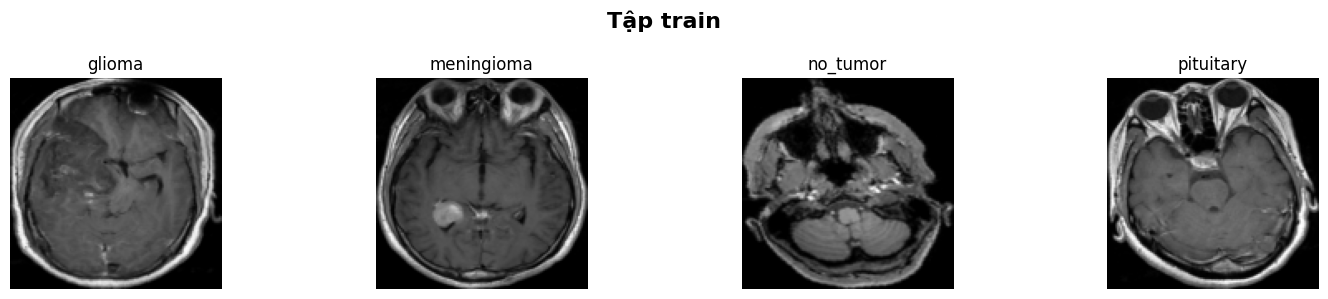

In [ ]:
imgshow_dataset(full_train_dataset_for_train, class_names, "Tập train")

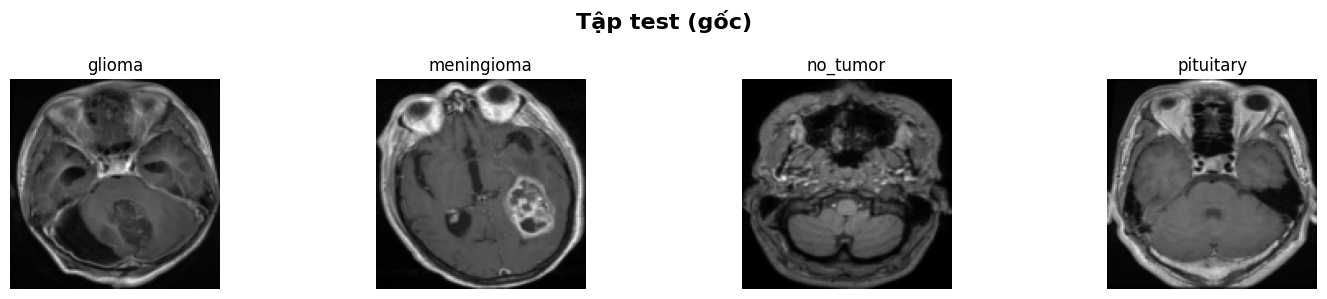

In [ ]:
imgshow_dataset(test_dataset, class_names, "Tập test (gốc)")

Định hình các lớp của mô hình

In [ ]:
class MLP(nn.Module):
    def __init__(self, num_classes, input_size=128*128):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.layers1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.drop1 = nn.Dropout(p=0.5)
        self.layers2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(p=0.2)
        self.layers3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = F.leaky_relu(self.bn1(self.layers1(x)))
        x = self.drop1(x)
        x = F.leaky_relu(self.bn2(self.layers2(x)))
        x = self.drop2(x)
        x = self.layers3(x)
        return x

Hàm cho chế độ train

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

Hàm cho chế độ dự đoán

In [ ]:
def validate(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / len(loader)
    acc = 100.0 * correct / total
    return avg_loss, acc

Hàm để bắt đầu train mô hình

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=NUM_EPOCHS, scheduler=None, patience=PATIENCE,
                save_path=None, device=DEVICE):
    """
    Huấn luyện mô hình với early stopping, tùy chọn lưu model tốt nhất.
    Trả về history và mô hình có trọng số tốt nhất.
    """
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if scheduler:
            scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f"Epoch {epoch+1:3d}/{num_epochs} | LR: {current_lr:.7f} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_weights = copy.deepcopy(model.state_dict())
            if save_path:
                torch.save(best_weights, save_path)
                print(f"   --> Đã lưu model tốt nhất tại {save_path}")
        else:
            epochs_no_improve += 1
            print(f"   EarlyStopping counter: {epochs_no_improve}/{patience}")
            if epochs_no_improve >= patience:
                print(f"=== EARLY STOPPING tại epoch {epoch+1} ===")
                break


    model.load_state_dict(best_weights)
    return history

Chạy dự đoán trên tập test

In [ ]:
def evaluate_model(model, test_loader, class_names, device=DEVICE):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"--- Đánh giá trên tập Test ---")
    print(f"Overall Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:\n", report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix (Acc: {acc*100:.2f}%)')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()
    return acc, cm

Hiển thị biểu đồ của giá trị loss và accuracy

In [ ]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], 'g-', label='Val Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

Thiết lập cho chạy model theo cách chia dữ liệu 1 lần

Epoch   1/150 | LR: 0.0000150 | Train Loss: 1.1650 | Val Loss: 0.9684 | Val Acc: 62.30%
   --> Đã lưu model tốt nhất tại /content/drive/MyDrive/Colab Notebooks/Brics2025_MLP_kfold/best_mlp_model.pth
Epoch   2/150 | LR: 0.0000150 | Train Loss: 0.9752 | Val Loss: 0.8510 | Val Acc: 70.70%
   --> Đã lưu model tốt nhất tại /content/drive/MyDrive/Colab Notebooks/Brics2025_MLP_kfold/best_mlp_model.pth
Epoch   3/150 | LR: 0.0000150 | Train Loss: 0.8968 | Val Loss: 0.8168 | Val Acc: 74.30%
   --> Đã lưu model tốt nhất tại /content/drive/MyDrive/Colab Notebooks/Brics2025_MLP_kfold/best_mlp_model.pth
Epoch   4/150 | LR: 0.0000150 | Train Loss: 0.8411 | Val Loss: 0.7625 | Val Acc: 75.70%
   --> Đã lưu model tốt nhất tại /content/drive/MyDrive/Colab Notebooks/Brics2025_MLP_kfold/best_mlp_model.pth
Epoch   5/150 | LR: 0.0000150 | Train Loss: 0.8123 | Val Loss: 0.7214 | Val Acc: 77.80%
   --> Đã lưu model tốt nhất tại /content/drive/MyDrive/Colab Notebooks/Brics2025_MLP_kfold/best_mlp_model.pth
Epoch

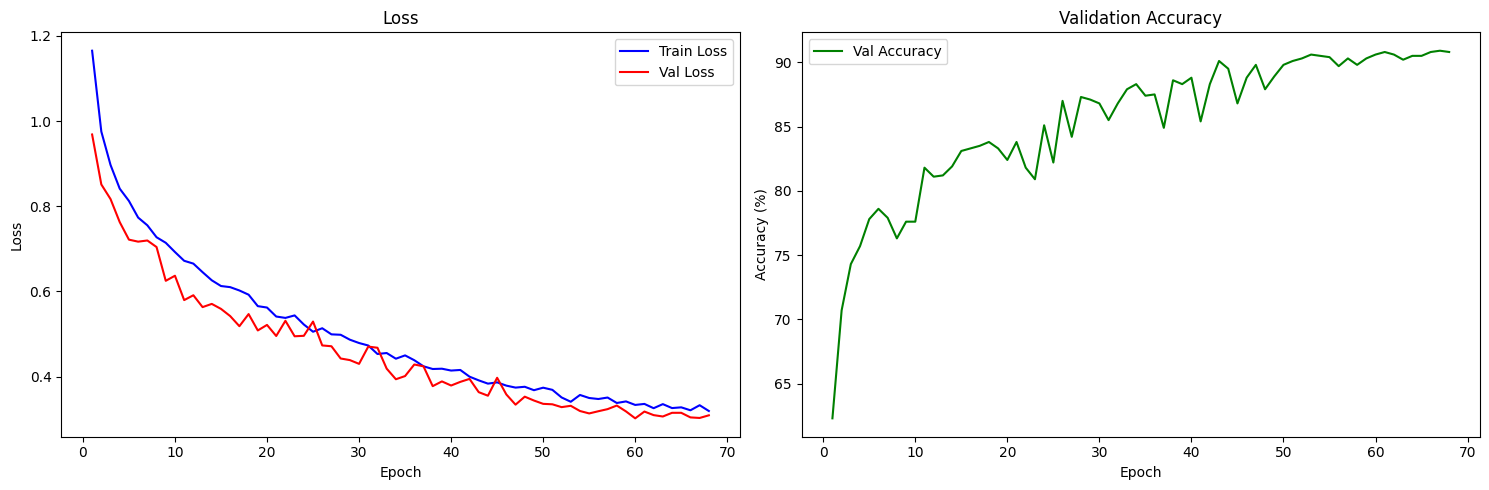

--- Đánh giá trên tập Test ---
Overall Accuracy: 90.00%

Classification Report:
               precision    recall  f1-score   support

      glioma       0.90      0.86      0.88       254
  meningioma       0.87      0.86      0.87       306
    no_tumor       0.88      0.90      0.89       140
   pituitary       0.93      0.97      0.95       300

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



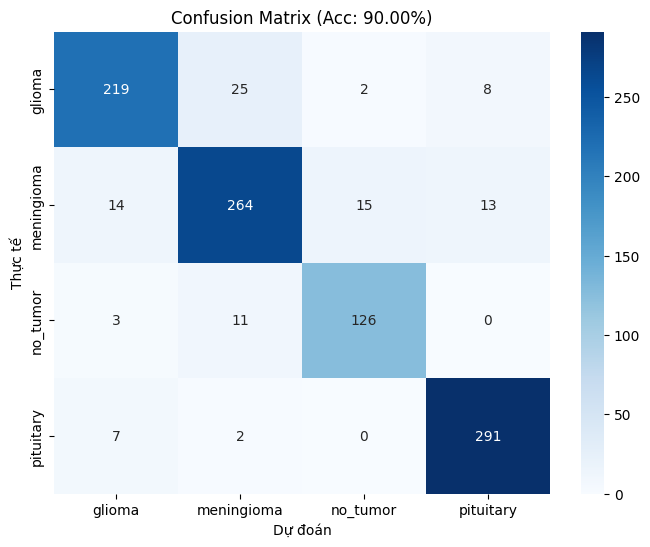

(0.9,
 array([[219,  25,   2,   8],
        [ 14, 264,  15,  13],
        [  3,  11, 126,   0],
        [  7,   2,   0, 291]]))

In [ ]:
# Tạo data loaders
train_ds, val_ds, _, _ = get_default_split(val_ratio=0.2)
train_loader, val_loader = create_dataloaders(train_ds, val_ds, batch_size=BATCH_SIZE)

# Khởi tạo model, loss, optimizer, scheduler
model = MLP(num_classes).to(DEVICE)
weight_tensor = torch.FloatTensor(WEIGHT_CLASS).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Huấn luyện (tùy chọn lưu)
history = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=NUM_EPOCHS, scheduler=scheduler, patience=8,
    save_path=MODEL_PATH, device=DEVICE
)


plot_history(history)


evaluate_model(model, test_loader, class_names, device=DEVICE)

Thiết lập cho chạy model theo cách k fold

In [ ]:
# Lấy danh sách chia fold
kfold_splits = get_kfold_splits(n_splits=N_SPLITS)

fold_accuracies = []          # Lưu accuracy trên test set từng fold
fold_val_accuracies = []      # Acc validation cuối cùng của fold
all_fold_histories = []       # Lưu history từng fold

for fold, (train_idx, val_idx) in enumerate(kfold_splits):
    print(f"\n{'='*20} FOLD {fold+1}/{N_SPLITS} {'='*20}")

    # 1. Tạo Subset cho fold này (train và val)
    train_subset = Subset(full_train_dataset_for_train, train_idx)
    val_subset = Subset(full_train_dataset_for_val, val_idx)

    # 2. Tạo DataLoader
    train_loader, val_loader = create_dataloaders(train_subset, val_subset, batch_size=BATCH_SIZE)
    print(f"Train samples: {len(train_subset)}, Val samples: {len(val_subset)}")

    # 3. Khởi tạo lại model, loss, optimizer, scheduler cho mỗi fold
    model = MLP(num_classes).to(DEVICE)
    weight_tensor = torch.FloatTensor(WEIGHT_CLASS).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # 4. Huấn luyện
    history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=NUM_EPOCHS, scheduler=scheduler, patience=PATIENCE,
        save_path=None,   # Không ghi đè file chính trong quá trình fold
        device=DEVICE
    )
    all_fold_histories.append(history)

    # 5. Đánh giá trên tập test độc lập
    print(f"\nĐánh giá fold {fold+1} trên tập test:")
    test_acc, _ = evaluate_model(model, test_loader, class_names, device=DEVICE)
    fold_accuracies.append(test_acc)
    fold_val_accuracies.append(history['val_acc'][-1])  # Acc val cuối cùng

# Tổng hợp kết quả K‑Fold
print("\n\n" + "="*50)
print("KẾT QUẢ CROSS-VALIDATION (K-Fold)")
print("="*50)
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1}: Test Accuracy = {acc*100:.2f}%")
mean_acc = np.mean(fold_accuracies) * 100
std_acc = np.std(fold_accuracies) * 100
print(f"\nTrung bình Test Accuracy: {mean_acc:.2f}% (±{std_acc:.2f}%)")

# Vẽ biểu đồ kết quả từng fold
plt.figure(figsize=(8,5))
plt.bar(range(1, N_SPLITS+1), [a*100 for a in fold_accuracies], tick_label=[f'Fold {i+1}' for i in range(N_SPLITS)])
plt.axhline(mean_acc, color='r', linestyle='--', label=f'Mean: {mean_acc:.2f}%')
plt.xlabel('Fold')
plt.ylabel('Test Accuracy (%)')
plt.title('K-Fold Cross-Validation Results')
plt.legend()
plt.show()

### Load trained weights and evaluate on Test Set

Loading weights from: /content/drive/MyDrive/Colab Notebooks/Brics2025_MLP_kfold/best_mlp_model.pth
--- Đánh giá trên tập Test ---
Overall Accuracy: 72.33%

Classification Report:
               precision    recall  f1-score   support

      glioma       0.71      0.66      0.69       308
  meningioma       0.67      0.87      0.76       404
    no_tumor       0.77      0.56      0.65       301
   pituitary       0.82      0.76      0.79       212

    accuracy                           0.72      1225
   macro avg       0.74      0.71      0.72      1225
weighted avg       0.73      0.72      0.72      1225



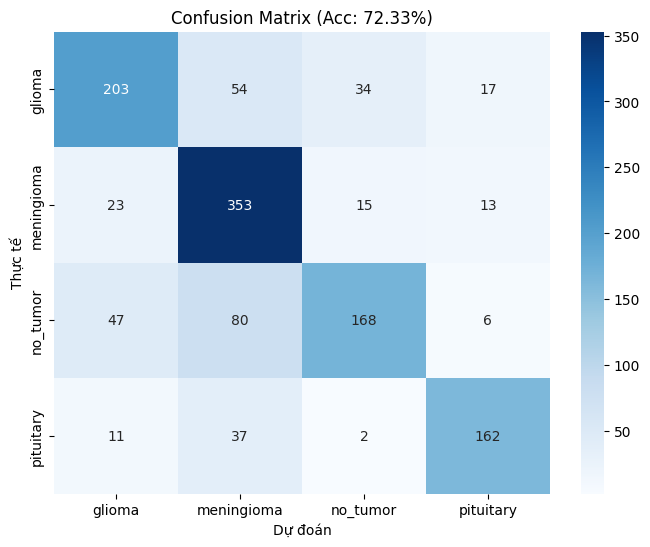

--- Đánh giá trên tập Test ---
Overall Accuracy: 90.00%

Classification Report:
               precision    recall  f1-score   support

      glioma       0.90      0.86      0.88       254
  meningioma       0.87      0.86      0.87       306
    no_tumor       0.88      0.90      0.89       140
   pituitary       0.93      0.97      0.95       300

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



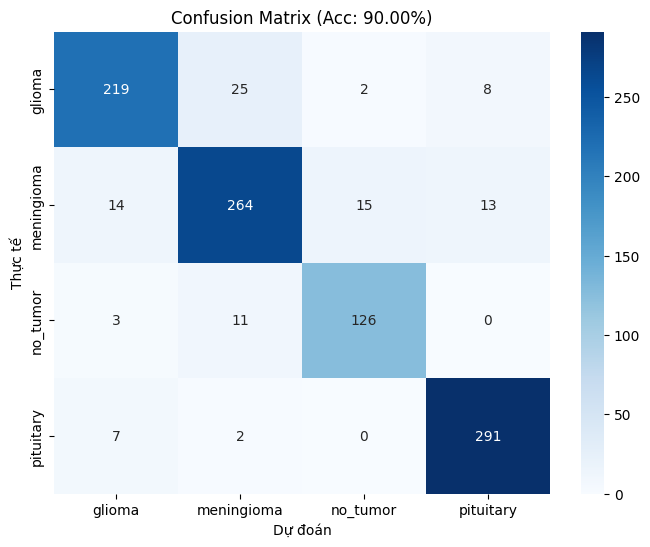

In [ ]:
if os.path.exists(MODEL_PATH):
    # Initialize the model architecture
    eval_model = MLP(num_classes).to(DEVICE)

    # Load the state dictionary
    print(f"Loading weights from: {MODEL_PATH}")
    eval_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

    # Run evaluation
    test_acc, cm = evaluate_model(eval_model, test_loader2, class_names, device=DEVICE)
else:
    print(f"Error: Model file not found at {MODEL_PATH}. Please check the path or ensure the model was saved.")